<a href="https://colab.research.google.com/github/ehisolojo/Montra-Hospitality-Guest-Experience-Analytics/blob/main/Montra_Guest_Experience_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install psycopg2-binary sqlalchemy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 36.6 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
from sqlalchemy import create_engine
import pandas as pd

try:
    # Get the database connection string securely from Colab Secrets
    DATABASE_URL = userdata.get("DATABASE_URL")
except Exception as e:
    print("Error loading DATABASE_URL from Colab Secrets!")
    print("Please make sure you have added 'DATABASE_URL' to the 'Secrets' tab (key icon in the left sidebar) and toggled 'Notebook access' to ON.")
    print(f"Original Error: {e}")
    DATABASE_URL = None

if DATABASE_URL:
    try:
        # Create the database connection
        engine = create_engine(DATABASE_URL)

        # Test the connection
        with engine.connect() as connection:
            # Using text() is recommended in SQLAlchemy 2.0
            from sqlalchemy import text
            result = connection.execute(text("SELECT current_database(), current_user;"))
            print("Connection successful! Database and User details:")
            print(result.fetchone())
    except Exception as db_err:
        print(f"Database connection failed: {db_err}")
else:
    print("Execution halted because DATABASE_URL is not configured.")

TimeoutException: Requesting secret DATABASE_URL timed out. Secrets can only be fetched when running from the Colab UI.

In [4]:
from google.colab import userdata

secret = userdata.get("DATABASE_URL")

print("Secret retrieved successfully:", secret is not None)

Secret retrieved successfully: True


In [7]:
from google.colab import userdata
from sqlalchemy import create_engine, text

# Retrieve the connection string securely
DATABASE_URL = userdata.get("DATABASE_URL")

# Create database engine
engine = create_engine(DATABASE_URL)

# Test the connection
with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    )
    print("Database connection successful!")
    print(result.fetchone())

Database connection successful!
('neondb', 'neondb_owner')


In [10]:
from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(text("""
        SELECT table_schema, table_name
        FROM information_schema.tables
        WHERE table_type = 'BASE TABLE'
        AND table_schema NOT IN ('pg_catalog', 'information_schema')
        ORDER BY table_schema, table_name;
    """))

    for row in result:
        print(row)

('public', 'bookings')
('public', 'guests')
('public', 'hotels')
('public', 'reviews')


In [13]:
from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(text("""
        SELECT
            table_name,
            column_name,
            data_type
        FROM information_schema.columns
        WHERE table_schema = 'public'
        AND table_name IN ('bookings', 'guests', 'hotels', 'reviews')
        ORDER BY table_name, ordinal_position;
    """))

    for row in result:
        print(row)

('bookings', 'booking_id', 'bigint')
('bookings', 'guest_id', 'bigint')
('bookings', 'hotel_id', 'bigint')
('bookings', 'room_type', 'text')
('bookings', 'booking_channel', 'text')
('bookings', 'check_in_date', 'text')
('bookings', 'check_out_date', 'text')
('bookings', 'total_amount', 'double precision')
('bookings', 'stay_duration', 'bigint')
('guests', 'guest_id', 'bigint')
('guests', 'customer_type', 'text')
('guests', 'loyalty_status', 'text')
('guests', 'country', 'text')
('guests', 'previous_stays', 'bigint')
('hotels', 'hotel_id', 'bigint')
('hotels', 'hotel_name', 'text')
('hotels', 'location', 'text')
('hotels', 'star_rating', 'bigint')
('hotels', 'total_rooms', 'bigint')
('reviews', 'review_id', 'bigint')
('reviews', 'booking_id', 'bigint')
('reviews', 'guest_id', 'bigint')
('reviews', 'hotel_id', 'bigint')
('reviews', 'review_text', 'text')
('reviews', 'rating_score', 'double precision')
('reviews', 'review_date', 'text')
('reviews', 'sentiment_label', 'text')


In [15]:
from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(text("""
        SELECT
            (SELECT COUNT(*) FROM bookings) AS bookings_count,
            (SELECT COUNT(*) FROM guests) AS guests_count,
            (SELECT COUNT(*) FROM hotels) AS hotels_count,
            (SELECT COUNT(*) FROM reviews) AS reviews_count;
    """))

    print(result.fetchone())

(35000, 12000, 25, 35000)


In [16]:
from sqlalchemy import text
import pandas as pd

tables = ["reviews", "bookings", "guests", "hotels"]

for table in tables:
    print(f"\n{'='*60}")
    print(f"{table.upper()} — SAMPLE RECORDS")
    print(f"{'='*60}")

    query = text(f"SELECT * FROM {table} LIMIT 5;")

    with engine.connect() as connection:
        df_sample = pd.read_sql(query, connection)

    display(df_sample)


REVIEWS — SAMPLE RECORDS


,review_id,booking_id,guest_id,hotel_id,review_text,rating_score,review_date,sentiment_label
0,1,1,6699,18,The overall price was fair for what we paid. M...,3.2,2025-06-02,neutral
1,2,2,11380,23,The room was nothing out of the ordinary for w...,4.0,2025-01-22,positive
2,3,3,4812,13,"Unfortunately, the pool was outdated — it clea...",1.9,2025-03-13,negative
3,4,4,982,12,We were disappointed that the neighborhood was...,2.2,2026-03-18,negative
4,5,5,615,5,The room service was standard hotel fare for w...,3.3,2025-03-03,neutral



BOOKINGS — SAMPLE RECORDS


,booking_id,guest_id,hotel_id,room_type,booking_channel,check_in_date,check_out_date,total_amount,stay_duration
0,1,6699,18,Suite,Direct Website,2025-05-25,2025-05-26,296.44,1
1,2,11380,23,Deluxe,Corporate Portal,2025-01-09,2025-01-13,483.56,4
2,3,4812,13,Executive,Travel Agent,2025-03-04,2025-03-06,415.59,2
3,4,982,12,Family Room,Airbnb,2026-03-06,2026-03-09,601.18,3
4,5,615,5,Deluxe,Expedia,2025-02-25,2025-03-02,603.85,5



GUESTS — SAMPLE RECORDS


,guest_id,customer_type,loyalty_status,country,previous_stays
0,1,Leisure,None,Australia,0
1,2,Leisure,None,Germany,1
2,3,Business,Gold,United Kingdom,0
3,4,Family,Silver,United Arab Emirates,8
4,5,Corporate,None,France,0



HOTELS — SAMPLE RECORDS


,hotel_id,hotel_name,location,star_rating,total_rooms
0,1,The Birmingham Grand,Birmingham,4,254
1,2,The London Heritage,London,5,234
2,3,The Oxford Boutique,Oxford,3,146
3,4,The Glasgow Heritage,Glasgow,3,84
4,5,Glasgow Metropolitan,Glasgow,4,214


In [17]:
from sqlalchemy import text
import pandas as pd

tables = ["reviews", "bookings", "guests", "hotels"]

for table in tables:
    print(f"\n{'='*60}")
    print(f"{table.upper()} — MISSING VALUES")
    print(f"{'='*60}")

    query = text(f"""
        SELECT *
        FROM {table};
    """)

    with engine.connect() as connection:
        df = pd.read_sql(query, connection)

    missing = df.isnull().sum()
    missing_pct = (df.isnull().mean() * 100).round(2)

    quality = pd.DataFrame({
        "Missing Count": missing,
        "Missing %": missing_pct
    })

    display(quality[quality["Missing Count"] > 0])


REVIEWS — MISSING VALUES


,Missing Count,Missing %



BOOKINGS — MISSING VALUES


,Missing Count,Missing %



GUESTS — MISSING VALUES


,Missing Count,Missing %
loyalty_status,6036,50.3



HOTELS — MISSING VALUES


,Missing Count,Missing %


In [18]:
query = text("""
    SELECT
        COALESCE(loyalty_status, 'MISSING') AS loyalty_status,
        COUNT(*) AS guest_count
    FROM guests
    GROUP BY loyalty_status
    ORDER BY guest_count DESC;
""")

with engine.connect() as connection:
    loyalty_df = pd.read_sql(query, connection)

display(loyalty_df)

,loyalty_status,guest_count
0,MISSING,6036
1,Silver,2951
2,Gold,1998
3,Platinum,1015


In [19]:
from sqlalchemy import text
import pandas as pd

checks = {
    "guests": "guest_id",
    "hotels": "hotel_id",
    "bookings": "booking_id",
    "reviews": "review_id"
}

for table, id_column in checks.items():
    query = text(f"""
        SELECT
            COUNT(*) AS total_rows,
            COUNT(DISTINCT {id_column}) AS unique_ids
        FROM {table};
    """)

    with engine.connect() as connection:
        result = connection.execute(query).fetchone()

    print(
        f"{table}: "
        f"total rows = {result[0]}, "
        f"unique {id_column} = {result[1]}"
    )

guests: total rows = 12000, unique guest_id = 12000
hotels: total rows = 25, unique hotel_id = 25
bookings: total rows = 35000, unique booking_id = 35000
reviews: total rows = 35000, unique review_id = 35000


In [20]:
relationship_checks = {
    "reviews → bookings": """
        SELECT COUNT(*)
        FROM reviews r
        LEFT JOIN bookings b ON r.booking_id = b.booking_id
        WHERE b.booking_id IS NULL;
    """,

    "reviews → guests": """
        SELECT COUNT(*)
        FROM reviews r
        LEFT JOIN guests g ON r.guest_id = g.guest_id
        WHERE g.guest_id IS NULL;
    """,

    "reviews → hotels": """
        SELECT COUNT(*)
        FROM reviews r
        LEFT JOIN hotels h ON r.hotel_id = h.hotel_id
        WHERE h.hotel_id IS NULL;
    """,

    "bookings → guests": """
        SELECT COUNT(*)
        FROM bookings b
        LEFT JOIN guests g ON b.guest_id = g.guest_id
        WHERE g.guest_id IS NULL;
    """,

    "bookings → hotels": """
        SELECT COUNT(*)
        FROM bookings b
        LEFT JOIN hotels h ON b.hotel_id = h.hotel_id
        WHERE h.hotel_id IS NULL;
    """
}

with engine.connect() as connection:
    for relationship, query in relationship_checks.items():
        result = connection.execute(text(query)).scalar()
        print(f"{relationship}: {result} unmatched records")

reviews → bookings: 0 unmatched records
reviews → guests: 0 unmatched records
reviews → hotels: 0 unmatched records
bookings → guests: 0 unmatched records
bookings → hotels: 0 unmatched records


In [21]:
query = text("""
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
            2
        ) AS percentage
    FROM reviews
    GROUP BY sentiment_label
    ORDER BY review_count DESC;
""")

with engine.connect() as connection:
    sentiment_distribution = pd.read_sql(query, connection)

display(sentiment_distribution)

,sentiment_label,review_count,percentage
0,neutral,13355,38.16
1,positive,11782,33.66
2,negative,9863,28.18


In [22]:
query = text("""
    SELECT
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating,
        AVG(rating_score) AS average_rating,
        COUNT(DISTINCT rating_score) AS distinct_ratings
    FROM reviews;
""")

with engine.connect() as connection:
    rating_summary = pd.read_sql(query, connection)

display(rating_summary)

,minimum_rating,maximum_rating,average_rating,distinct_ratings
0,1.0,5.0,3.027429,41


In [23]:
query = text("""
    SELECT
        rating_score,
        COUNT(*) AS review_count
    FROM reviews
    GROUP BY rating_score
    ORDER BY rating_score;
""")

with engine.connect() as connection:
    rating_distribution = pd.read_sql(query, connection)

display(rating_distribution)

OperationalError: (psycopg2.OperationalError) SSL connection has been closed unexpectedly

[SQL: 
    SELECT
        rating_score,
        COUNT(*) AS review_count
    FROM reviews
    GROUP BY rating_score
    ORDER BY rating_score;
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [24]:
from google.colab import userdata
from sqlalchemy import create_engine, text

DATABASE_URL = userdata.get("DATABASE_URL")

# Create a fresh database engine
engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,
    pool_recycle=300
)

# Test the fresh connection
with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database();")
    )
    print("Fresh connection successful:", result.fetchone()[0])

Fresh connection successful: neondb


In [25]:
query = text("""
    SELECT
        rating_score,
        COUNT(*) AS review_count
    FROM reviews
    GROUP BY rating_score
    ORDER BY rating_score;
""")

with engine.connect() as connection:
    rating_distribution = pd.read_sql(query, connection)

display(rating_distribution)

,rating_score,review_count
0,1.0,669
1,1.1,192
2,1.2,233
3,1.3,304
4,1.4,321
5,1.5,451
6,1.6,456
7,1.7,594
8,1.8,647
9,1.9,722


In [26]:
from sqlalchemy import text

query = text("""
    SELECT
        COUNT(*) AS total_reviews,
        COUNT(*) FILTER (WHERE review_text IS NULL) AS null_reviews,
        COUNT(*) FILTER (WHERE TRIM(review_text) = '') AS empty_reviews,
        COUNT(DISTINCT review_text) AS unique_review_texts,
        MIN(LENGTH(review_text)) AS shortest_review,
        MAX(LENGTH(review_text)) AS longest_review,
        ROUND(AVG(LENGTH(review_text)), 2) AS average_review_length
    FROM reviews;
""")

with engine.connect() as connection:
    review_quality = pd.read_sql(query, connection)

display(review_quality)

,total_reviews,null_reviews,empty_reviews,unique_review_texts,shortest_review,longest_review,average_review_length
0,35000,0,0,34536,67,280,171.91


In [27]:
query = text("""
    SELECT
        review_text,
        COUNT(*) AS occurrence_count
    FROM reviews
    GROUP BY review_text
    HAVING COUNT(*) > 1
    ORDER BY occurrence_count DESC, review_text
    LIMIT 20;
""")

with engine.connect() as connection:
    duplicate_reviews = pd.read_sql(query, connection)

display(duplicate_reviews)

,review_text,occurrence_count
0,The cost of the stay was in line with similar ...,6
1,The pricing left a lot to be desired; we found...,6
2,I'd describe the cost of the stay as in line w...,5
3,Overall getting around from the hotel was not ...,5
4,Overall the cost of the stay was about what we...,5
5,Overall the cost of the stay was in line with ...,5
6,I'd describe getting around from the hotel as ...,4
7,I'd describe getting around from the hotel as ...,4
8,I'd describe our arrival experience as fine — ...,4
9,I'd describe the cost of the stay as fair — it...,4


In [29]:
query = text("""
    SELECT
        review_id,
        booking_id,
        guest_id,
        hotel_id,
        review_text,
        rating_score,
        sentiment_label
    FROM reviews
    WHERE review_text = (
        SELECT review_text
        FROM reviews
        GROUP BY review_text
        HAVING COUNT(*) = 6
        ORDER BY review_text
        LIMIT 1
    )
    ORDER BY review_id;
""")

with engine.connect() as connection:
    repeated_review_details = pd.read_sql(query, connection)

display(repeated_review_details)

,review_id,booking_id,guest_id,hotel_id,review_text,rating_score,sentiment_label
0,6579,6579,7733,2,The cost of the stay was in line with similar ...,4.6,positive
1,15780,15780,2894,3,The cost of the stay was in line with similar ...,3.0,neutral
2,20629,20629,9991,12,The cost of the stay was in line with similar ...,3.2,neutral
3,27814,27814,6274,17,The cost of the stay was in line with similar ...,3.2,neutral
4,32061,32061,3709,4,The cost of the stay was in line with similar ...,3.0,neutral
5,32983,32983,6118,24,The cost of the stay was in line with similar ...,3.0,neutral


In [30]:
query = text("""
    SELECT
        rating_score,
        sentiment_label,
        COUNT(*) AS review_count
    FROM reviews
    GROUP BY rating_score, sentiment_label
    ORDER BY rating_score, sentiment_label;
""")

with engine.connect() as connection:
    rating_sentiment = pd.read_sql(query, connection)

display(rating_sentiment)

,rating_score,sentiment_label,review_count
0,1.0,negative,654
1,1.0,neutral,15
2,1.1,negative,185
3,1.1,neutral,7
4,1.2,negative,227
...,...,...,...
87,4.8,positive,265
88,4.9,neutral,5
89,4.9,positive,197
90,5.0,neutral,19


In [31]:
query = text("""
    SELECT
        rating_score,
        sentiment_label,
        COUNT(*) AS review_count
    FROM reviews
    GROUP BY rating_score, sentiment_label
    ORDER BY rating_score, sentiment_label;
""")

with engine.connect() as connection:
    rating_sentiment = pd.read_sql(query, connection)

# Calculate percentage within each rating
rating_sentiment["rating_total"] = (
    rating_sentiment.groupby("rating_score")["review_count"]
    .transform("sum")
)

rating_sentiment["percentage"] = (
    rating_sentiment["review_count"] /
    rating_sentiment["rating_total"] * 100
).round(2)

display(rating_sentiment)

,rating_score,sentiment_label,review_count,rating_total,percentage
0,1.0,negative,654,669,97.76
1,1.0,neutral,15,669,2.24
2,1.1,negative,185,192,96.35
3,1.1,neutral,7,192,3.65
4,1.2,negative,227,233,97.42
...,...,...,...,...,...
87,4.8,positive,265,270,98.15
88,4.9,neutral,5,202,2.48
89,4.9,positive,197,202,97.52
90,5.0,neutral,19,804,2.36


In [32]:
query = text("""
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating,
        ROUND(AVG(rating_score), 2) AS average_rating
    FROM reviews
    GROUP BY sentiment_label
    ORDER BY sentiment_label;
""")

with engine.connect() as connection:
    sentiment_rating_summary = pd.read_sql(query, connection)

display(sentiment_rating_summary)

ProgrammingError: (psycopg2.errors.UndefinedFunction) function round(double precision, integer) does not exist
LINE 7:         ROUND(AVG(rating_score), 2) AS average_rating
                ^
HINT:  No function matches the given name and argument types. You might need to add explicit type casts.

[SQL: 
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating,
        ROUND(AVG(rating_score), 2) AS average_rating
    FROM reviews
    GROUP BY sentiment_label
    ORDER BY sentiment_label;
]
(Background on this error at: https://sqlalche.me/e/20/f405)

In [1]:
query = text("""
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating,
        ROUND(AVG(rating_score)::numeric, 2) AS average_rating
    FROM reviews
    GROUP BY sentiment_label
    ORDER BY sentiment_label;
""")

with engine.connect() as connection:
    sentiment_rating_summary = pd.read_sql(query, connection)

display(sentiment_rating_summary)

NameError: name 'text' is not defined

In [5]:
from sqlalchemy import text

In [6]:
query = text("""
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating,
        ROUND(AVG(rating_score)::numeric, 2) AS average_rating
    FROM reviews
    GROUP BY sentiment_label
    ORDER BY sentiment_label;
""")

with engine.connect() as connection:
    sentiment_rating_summary = pd.read_sql(query, connection)

display(sentiment_rating_summary)

NameError: name 'engine' is not defined

In [7]:
from google.colab import userdata
from sqlalchemy import create_engine, text

DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL)

print("Database engine created successfully!")

Database engine created successfully!


In [8]:
with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    )
    print("Database connection successful!")
    print(result.fetchone())

Database connection successful!
('neondb', 'neondb_owner')


In [9]:
query = text("""
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating,
        ROUND(AVG(rating_score)::numeric, 2) AS average_rating
    FROM reviews
    GROUP BY sentiment_label
    ORDER BY sentiment_label;
""")

with engine.connect() as connection:
    sentiment_rating_summary = pd.read_sql(query, connection)

display(sentiment_rating_summary)

NameError: name 'pd' is not defined

In [10]:
import pandas as pd

In [11]:
query = text("""
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating,
        ROUND(AVG(rating_score)::numeric, 2) AS average_rating
    FROM reviews
    GROUP BY sentiment_label
    ORDER BY sentiment_label;
""")

with engine.connect() as connection:
    sentiment_rating_summary = pd.read_sql(query, connection)

display(sentiment_rating_summary)

OperationalError: (psycopg2.OperationalError) SSL connection has been closed unexpectedly

[SQL: 
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating,
        ROUND(AVG(rating_score)::numeric, 2) AS average_rating
    FROM reviews
    GROUP BY sentiment_label
    ORDER BY sentiment_label;
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [12]:
from google.colab import userdata
from sqlalchemy import create_engine, text

DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL)

print("Database engine recreated successfully!")

TimeoutException: Requesting secret DATABASE_URL timed out. Secrets can only be fetched when running from the Colab UI.

In [13]:
from google.colab import userdata

DATABASE_URL = userdata.get("DATABASE_URL")

print("DATABASE_URL retrieved successfully:", DATABASE_URL is not None)

DATABASE_URL retrieved successfully: True


In [14]:
from sqlalchemy import create_engine, text

engine = create_engine(DATABASE_URL)

print("Database engine recreated successfully!")

Database engine recreated successfully!


In [15]:
with engine.connect() as connection:
    result = connection.execute(
        text("SELECT 1;")
    )
    print("Connection test successful!")
    print(result.fetchone())

Connection test successful!
(1,)


In [16]:
query = text("""
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating,
        ROUND(AVG(rating_score)::numeric, 2) AS average_rating
    FROM reviews
    GROUP BY sentiment_label
    ORDER BY sentiment_label;
""")

with engine.connect() as connection:
    sentiment_rating_summary = pd.read_sql(query, connection)

display(sentiment_rating_summary)

,sentiment_label,review_count,minimum_rating,maximum_rating,average_rating
0,negative,9863,1.0,3.4,1.94
1,neutral,13355,1.0,5.0,2.96
2,positive,11782,2.5,5.0,4.01


In [1]:
# STEP 1: Overall Volume of Guest Reviews

query = text("""
    SELECT COUNT(*) AS total_reviews
    FROM reviews;
""")

with engine.connect() as connection:
    review_volume = pd.read_sql(query, connection)

display(review_volume)

NameError: name 'text' is not defined

In [ ]:
from sqlalchemy import text


In [2]:
# STEP 1: Overall Volume of Guest Reviews

query = text("""
    SELECT COUNT(*) AS total_reviews
    FROM reviews;
""")

with engine.connect() as connection:
    review_volume = pd.read_sql(query, connection)

display(review_volume)

NameError: name 'text' is not defined

In [3]:
from sqlalchemy import text
print("SQLAlchemy text imported successfully")

SQLAlchemy text imported successfully


In [4]:
# STEP 1: Overall Volume of Guest Reviews

query = text("""
    SELECT COUNT(*) AS total_reviews
    FROM public.reviews;
""")

with engine.connect() as connection:
    review_volume = pd.read_sql(query, connection)

display(review_volume)

NameError: name 'engine' is not defined

In [5]:
from google.colab import userdata
from sqlalchemy import create_engine, text

DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL)

print("Database engine recreated successfully")

Database engine recreated successfully


In [6]:
with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    )
    print("Database connection successful!")
    print(result.fetchone())

Database connection successful!
('neondb', 'neondb_owner')


In [7]:
# STEP 1: Overall Volume of Guest Reviews

query = text("""
    SELECT COUNT(*) AS total_reviews
    FROM public.reviews;
""")

with engine.connect() as connection:
    review_volume = pd.read_sql(query, connection)

display(review_volume)

NameError: name 'pd' is not defined

In [8]:
# STEP 1: Overall Volume of Guest Reviews

query = text("""
    SELECT COUNT(*) AS total_reviews
    FROM public.reviews;
""")

with engine.connect() as connection:
    review_volume = pd.read_sql(query, connection)

display(review_volume)

NameError: name 'pd' is not defined

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

print("Pandas, Matplotlib, and SQLAlchemy imports are ready.")

Pandas, Matplotlib, and SQLAlchemy imports are ready.


In [2]:
# Project Setup: Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from google.colab import userdata

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [3]:
# Reconnect to the Neon PostgreSQL database

DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL)

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    )
    print("Database connection successful!")
    print(result.fetchone())

Database connection successful!
('neondb', 'neondb_owner')


## 1. Overall Volume of Guest Reviews

This analysis examines the total number of guest reviews available in the dataset. Understanding the volume of available guest feedback provides an initial view of the amount of review data available for subsequent guest experience, NLP, topic modelling, and sentiment analysis.

In [1]:
# Calculate the total number of guest reviews

query = text("""
    SELECT COUNT(*) AS total_reviews
    FROM public.reviews;
""")

with engine.connect() as connection:
    review_volume = pd.read_sql(query, connection)

display(review_volume)

NameError: name 'text' is not defined

In [4]:
# Calculate the total number of guest reviews

query = text("""
    SELECT COUNT(*) AS total_reviews
    FROM public.reviews;
""")

with engine.connect() as connection:
    review_volume = pd.read_sql(query, connection)

display(review_volume)

,total_reviews
0,35000


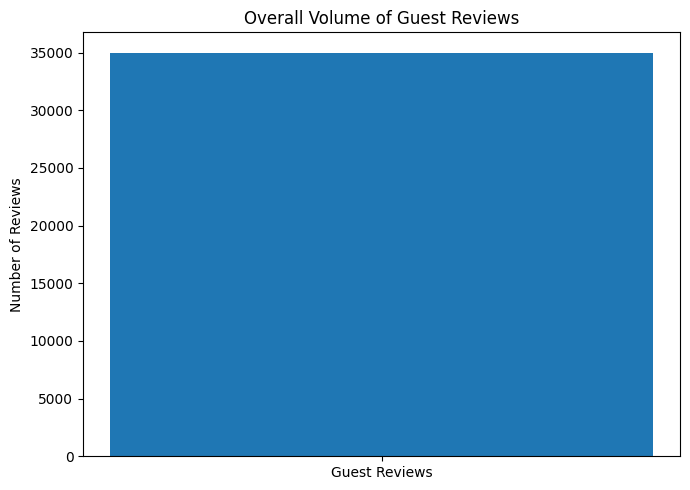

In [5]:
# Visualize the overall volume of guest reviews

total_reviews = review_volume.loc[0, "total_reviews"]

plt.figure(figsize=(7, 5))
plt.bar(["Guest Reviews"], [total_reviews])

plt.title("Overall Volume of Guest Reviews")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

### Finding and Interpretation

The dataset contains **35,000 guest reviews**. This represents the total volume of guest feedback available for the exploratory analysis.

The available review records provide the primary source of unstructured guest feedback for subsequent NLP processing, topic modelling, and sentiment analysis.

## 2. Rating Distribution

This analysis examines the distribution of guest rating scores in the dataset. Understanding how ratings are distributed provides an initial view of overall guest satisfaction and helps identify the range of ratings represented in the review data.

In [6]:
# Calculate the distribution of guest rating scores

query = text("""
    SELECT
        rating_score,
        COUNT(*) AS review_count
    FROM public.reviews
    GROUP BY rating_score
    ORDER BY rating_score;
""")

with engine.connect() as connection:
    rating_distribution = pd.read_sql(query, connection)

display(rating_distribution)

,rating_score,review_count
0,1.0,669
1,1.1,192
2,1.2,233
3,1.3,304
4,1.4,321
5,1.5,451
6,1.6,456
7,1.7,594
8,1.8,647
9,1.9,722


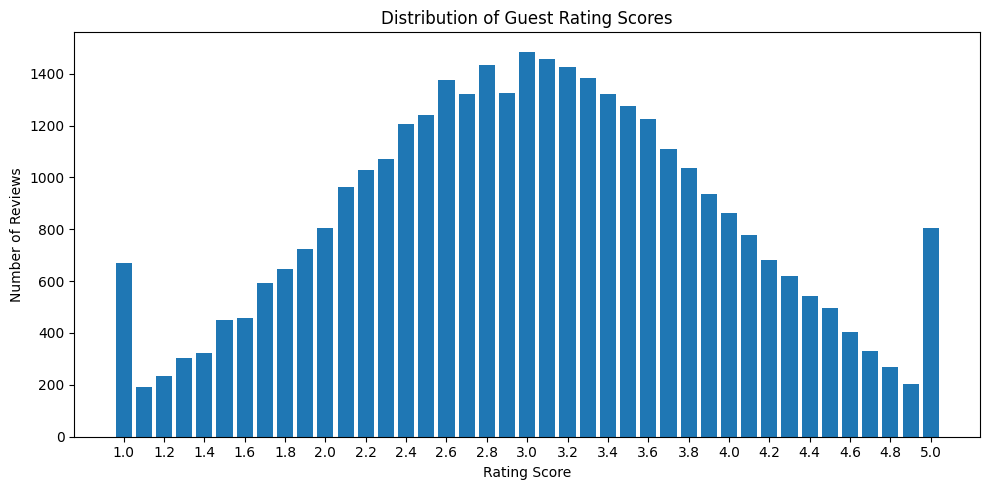

In [7]:
# Visualize the distribution of rating scores

plt.figure(figsize=(10, 5))

plt.bar(
    rating_distribution["rating_score"],
    rating_distribution["review_count"],
    width=0.08
)

plt.title("Distribution of Guest Rating Scores")
plt.xlabel("Rating Score")
plt.ylabel("Number of Reviews")
plt.xticks(rating_distribution["rating_score"][::2])
plt.tight_layout()
plt.show()

### Finding and Interpretation

The guest ratings range from **1.0 to 5.0**, with rating values recorded at 0.1-point intervals.

The distribution shows that ratings are concentrated around the middle of the scale, with the highest number of reviews recorded at a rating of **3.0 (1,485 reviews)**. Ratings around the 2.4–3.4 range also have relatively high review counts, while the number of reviews generally decreases toward the higher end of the rating scale.

This indicates that the dataset contains a broad range of guest experiences rather than being concentrated only among highly positive ratings.

### Initial Business Insight

The presence of substantial review volumes across low, moderate, and high ratings provides an opportunity to investigate the factors associated with different levels of guest satisfaction. Further analysis of the review text will help identify the specific guest experience topics associated with these ratings.

## 3. Review Length and Basic Text Characteristics

This analysis examines the basic characteristics of the guest review text, including review length and the completeness of the review content. Understanding these characteristics helps assess the suitability of the review data for subsequent natural language processing and topic modelling.

In [9]:
# Refresh the database connection

DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL)

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    )
    print("Database connection refreshed successfully!")
    print(result.fetchone())

Database connection refreshed successfully!
('neondb', 'neondb_owner')


In [8]:
# Calculate basic review text characteristics
from google.colab import userdata
from sqlalchemy import create_engine, text
import pandas as pd

# Re-initialize engine to ensure a fresh, active connection
DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL, pool_pre_ping=True)

query = text("""
    SELECT
        COUNT(*) AS total_reviews,
        COUNT(*) FILTER (WHERE review_text IS NULL) AS null_reviews,
        COUNT(*) FILTER (WHERE TRIM(review_text) = '') AS empty_reviews,
        MIN(LENGTH(review_text)) AS shortest_review,
        MAX(LENGTH(review_text)) AS longest_review,
        ROUND(AVG(LENGTH(review_text))::numeric, 2) AS average_review_length
    FROM public.reviews;
""")

with engine.connect() as connection:
    review_text_summary = pd.read_sql(query, connection)

display(review_text_summary)

OperationalError: (psycopg2.OperationalError) SSL connection has been closed unexpectedly

[SQL: 
    SELECT
        COUNT(*) AS total_reviews,
        COUNT(*) FILTER (WHERE review_text IS NULL) AS null_reviews,
        COUNT(*) FILTER (WHERE TRIM(review_text) = '') AS empty_reviews,
        MIN(LENGTH(review_text)) AS shortest_review,
        MAX(LENGTH(review_text)) AS longest_review,
        ROUND(AVG(LENGTH(review_text))::numeric, 2) AS average_review_length
    FROM public.reviews;
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [10]:
# Calculate basic review text characteristics

query = text("""
    SELECT
        COUNT(*) AS total_reviews,
        COUNT(*) FILTER (WHERE review_text IS NULL) AS null_reviews,
        COUNT(*) FILTER (WHERE TRIM(review_text) = '') AS empty_reviews,
        MIN(LENGTH(review_text)) AS shortest_review,
        MAX(LENGTH(review_text)) AS longest_review,
        ROUND(AVG(LENGTH(review_text))::numeric, 2) AS average_review_length
    FROM public.reviews;
""")

with engine.connect() as connection:
    review_text_summary = pd.read_sql(query, connection)

display(review_text_summary)

,total_reviews,null_reviews,empty_reviews,shortest_review,longest_review,average_review_length
0,35000,0,0,67,280,171.91


In [11]:
# Calculate review length distribution for visualization

query = text("""
    SELECT
        LENGTH(review_text) AS review_length,
        COUNT(*) AS review_count
    FROM public.reviews
    GROUP BY LENGTH(review_text)
    ORDER BY review_length;
""")

with engine.connect() as connection:
    review_length_distribution = pd.read_sql(query, connection)

display(review_length_distribution.head())

,review_length,review_count
0,67,1
1,68,3
2,70,7
3,72,1
4,73,6


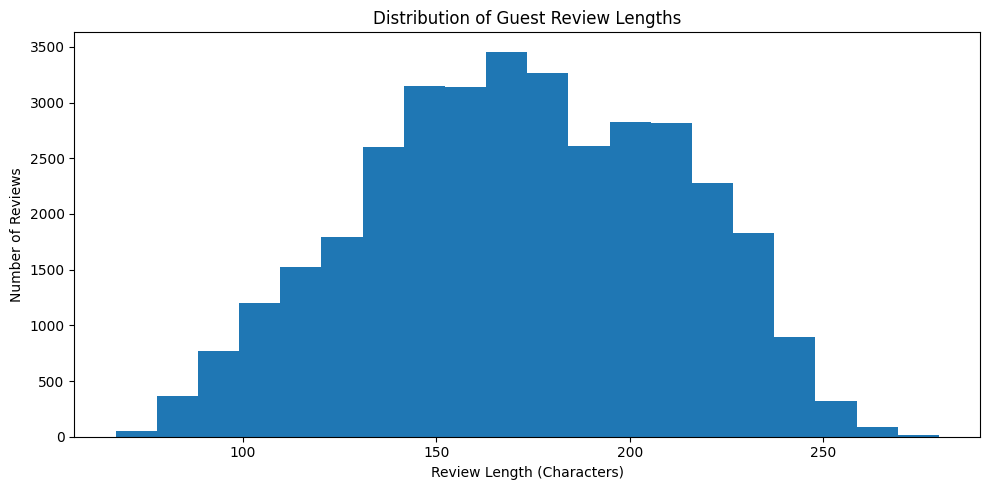

In [12]:
# Visualize the distribution of review lengths

plt.figure(figsize=(10, 5))

plt.hist(
    review_length_distribution["review_length"],
    weights=review_length_distribution["review_count"],
    bins=20
)

plt.title("Distribution of Guest Review Lengths")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

### Finding and Interpretation

The review texts range from **67 to 280 characters**, with an average length of approximately **171.91 characters**. The analysis also shows that there are **no missing or empty review texts** among the 35,000 reviews.

The distribution indicates that the reviews contain sufficient textual information for natural language processing while remaining relatively concise. This is suitable for subsequent NLP tasks such as topic modelling and sentiment analysis.

### Initial Business Insight

The availability of complete review text across the dataset provides a reliable source of guest feedback for identifying recurring guest experience topics and sentiment patterns. The variation in review length also provides an opportunity to examine how guests describe their experiences in different levels of detail.

## 4. Distribution of Reviews Across Hotels

This analysis examines how guest reviews are distributed across the different hotels in the dataset. Understanding the volume of reviews associated with each hotel helps determine whether guest feedback is evenly represented across properties and identifies hotels with relatively higher or lower levels of review coverage.

In [13]:
# Calculate the distribution of reviews across hotels

query = text("""
    SELECT
        h.hotel_id,
        h.hotel_name,
        COUNT(r.review_id) AS review_count
    FROM public.hotels h
    LEFT JOIN public.reviews r
        ON h.hotel_id = r.hotel_id
    GROUP BY h.hotel_id, h.hotel_name
    ORDER BY review_count DESC;
""")

with engine.connect() as connection:
    hotel_review_distribution = pd.read_sql(query, connection)

display(hotel_review_distribution)

,hotel_id,hotel_name,review_count
0,9,Edinburgh Riverside Hotel,1487
1,10,Southampton Park Hotel,1460
2,16,Glasgow Skyline Hotel,1445
3,11,Nottingham Riverside Hotel,1442
4,23,Nottingham Park Hotel,1430
5,5,Glasgow Metropolitan,1428
6,22,The Belfast Heritage,1427
7,14,Edinburgh Riverside Hotel,1422
8,12,Manchester Metropolitan,1418
9,13,The London Boutique,1418


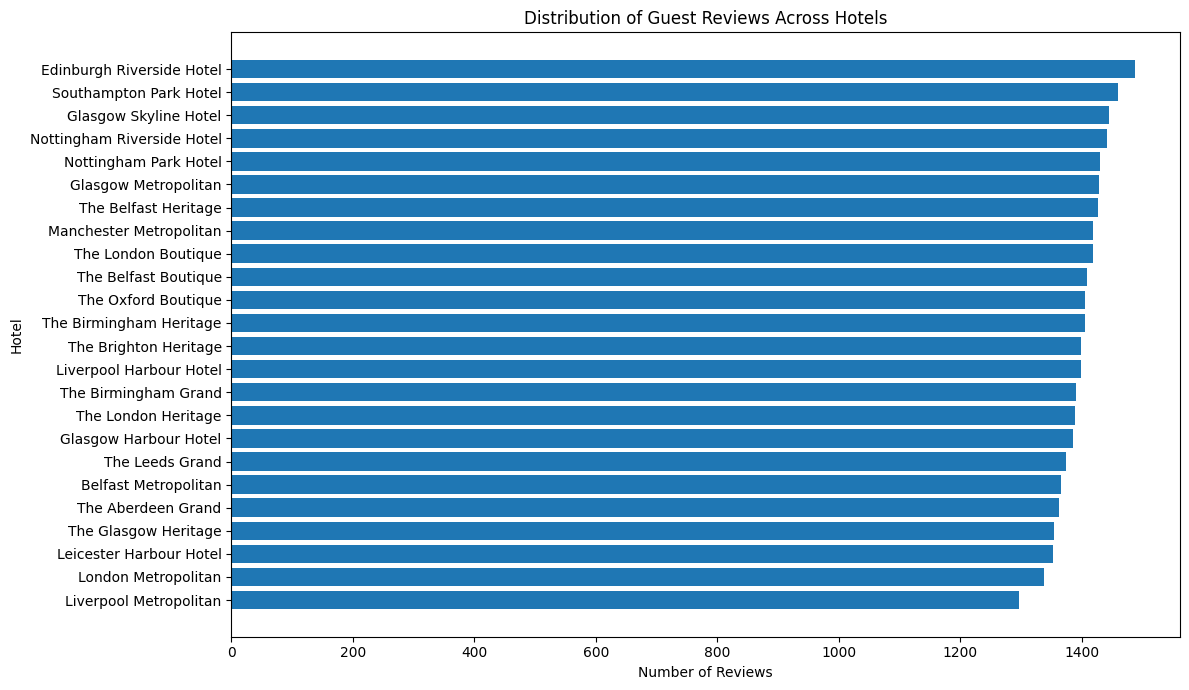

In [14]:
# Visualize the distribution of reviews across hotels

plt.figure(figsize=(12, 7))

plt.barh(
    hotel_review_distribution["hotel_name"],
    hotel_review_distribution["review_count"]
)

plt.title("Distribution of Guest Reviews Across Hotels")
plt.xlabel("Number of Reviews")
plt.ylabel("Hotel")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Finding and Interpretation

The analysis shows that all **25 hotels** are represented in the review dataset. The number of reviews per hotel ranges from **1,297 to 1,487 reviews**.

The review volumes are relatively close across the hotels, indicating that guest feedback is broadly distributed across the properties rather than being concentrated in only a small number of hotels.

The hotel with the highest number of reviews is **Edinburgh Riverside Hotel (1,487 reviews)**, while **Liverpool Metropolitan (1,297 reviews)** has the lowest number of reviews.

### Initial Business Insight

The relatively balanced distribution of reviews across the hotels provides a useful basis for comparing guest experiences between properties. Differences identified in ratings, topics, and sentiment can therefore be investigated across hotels without one property overwhelmingly dominating the review dataset.

In [17]:
# Refresh the Neon database connection

DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL)

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    )
    print("Database connection refreshed successfully!")
    print(result.fetchone())

Database connection refreshed successfully!
('neondb', 'neondb_owner')


## 5. Review Trends Over Time

This analysis examines how the volume of guest reviews changes over time using the review date. Identifying review trends helps determine whether guest feedback is consistently distributed across the available period and highlights periods with relatively higher or lower volumes of guest feedback.

In [16]:
# Analyze the trend in guest reviews over time

query = text("""
    SELECT
        DATE_TRUNC('month', review_date::date) AS review_month,
        COUNT(*) AS review_count
    FROM public.reviews
    GROUP BY review_month
    ORDER BY review_month;
""")

with engine.connect() as connection:
    review_trends = pd.read_sql(query, connection)

display(review_trends)

OperationalError: (psycopg2.OperationalError) SSL connection has been closed unexpectedly

[SQL: 
    SELECT
        DATE_TRUNC('month', review_date::date) AS review_month,
        COUNT(*) AS review_count
    FROM public.reviews
    GROUP BY review_month
    ORDER BY review_month;
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [18]:
# Analyze the trend in guest reviews over time

query = text("""
    SELECT
        DATE_TRUNC('month', review_date::date) AS review_month,
        COUNT(*) AS review_count
    FROM public.reviews
    GROUP BY review_month
    ORDER BY review_month;
""")

with engine.connect() as connection:
    review_trends = pd.read_sql(query, connection)

display(review_trends)

,review_month,review_count
0,2025-01-01 00:00:00+00:00,1406
1,2025-02-01 00:00:00+00:00,1927
2,2025-03-01 00:00:00+00:00,2058
3,2025-04-01 00:00:00+00:00,1967
4,2025-05-01 00:00:00+00:00,2064
5,2025-06-01 00:00:00+00:00,1955
6,2025-07-01 00:00:00+00:00,2072
7,2025-08-01 00:00:00+00:00,2002
8,2025-09-01 00:00:00+00:00,1932
9,2025-10-01 00:00:00+00:00,2109


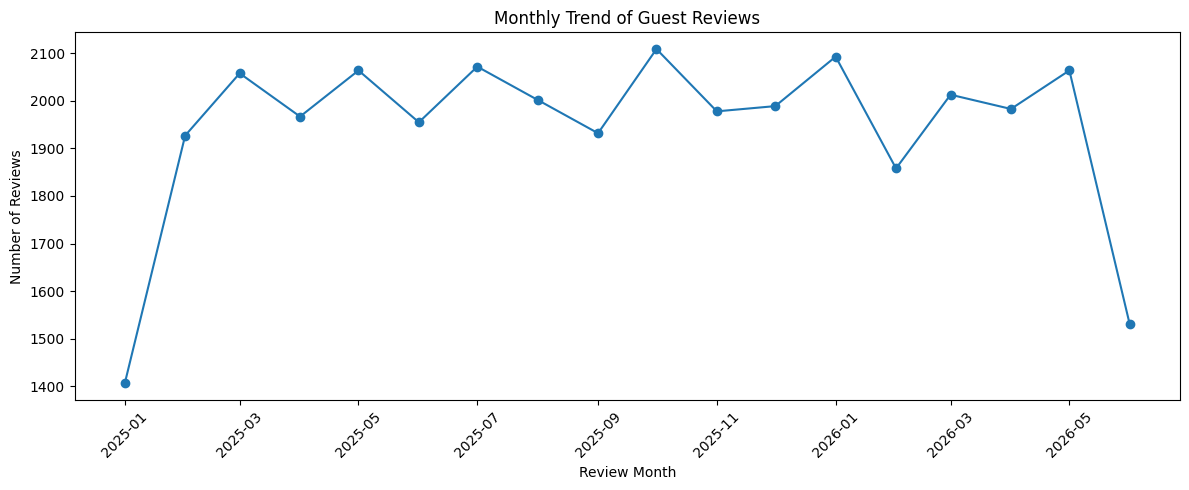

In [19]:
# Visualize the monthly trend in guest reviews

plt.figure(figsize=(12, 5))

plt.plot(
    review_trends["review_month"],
    review_trends["review_count"],
    marker="o"
)

plt.title("Monthly Trend of Guest Reviews")
plt.xlabel("Review Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Finding and Interpretation

The number of guest reviews varies across the analysis period from **January 2025 to June 2026**. Monthly review volumes generally remain around the 1,900–2,100 range for most of the period, although some months show noticeable increases or decreases.

The highest monthly review volume occurs in **October 2025, with 2,109 reviews**, while the lowest occurs in **January 2025, with 1,406 reviews**. A further decline is also observed in **June 2026, with 1,530 reviews**, compared with the preceding months.

Overall, the review data covers a continuous period with fluctuations in monthly review volume rather than a completely uniform pattern.

### Initial Business Insight

The variation in review volume over time provides useful context for interpreting guest feedback trends. Periods with higher or lower review volumes should be considered when investigating changes in guest sentiment, ratings, and experience topics.

Further analysis can determine whether changes in guest feedback topics or sentiment are associated with particular periods.

## 6. Relevant Guest Characteristics

This analysis examines selected guest characteristics available in the dataset, including customer type, loyalty status, country, and previous stays. Understanding these characteristics provides context for interpreting guest feedback and identifying differences in the profiles of guests represented in the review data.

In [20]:
# Examine relevant guest characteristics

query = text("""
    SELECT
        customer_type,
        loyalty_status,
        country,
        COUNT(*) AS guest_count,
        ROUND(AVG(previous_stays)::numeric, 2) AS average_previous_stays
    FROM public.guests
    GROUP BY customer_type, loyalty_status, country
    ORDER BY guest_count DESC;
""")

with engine.connect() as connection:
    guest_characteristics = pd.read_sql(query, connection)

display(guest_characteristics)

,customer_type,loyalty_status,country,guest_count,average_previous_stays
0,Leisure,None,United Kingdom,857,2.10
1,Business,None,United Kingdom,508,2.13
2,Leisure,Silver,United Kingdom,396,2.25
3,Corporate,None,United Kingdom,344,2.12
4,Leisure,Gold,United Kingdom,294,2.21
...,...,...,...,...,...
284,Group,Gold,Australia,1,4.00
285,Group,Gold,India,1,2.00
286,Business,Gold,India,1,0.00
287,Family,Platinum,Australia,1,6.00


In [21]:
# Summarize the main guest characteristics

customer_type_summary = (
    guest_characteristics
    .groupby("customer_type", as_index=False)["guest_count"]
    .sum()
    .sort_values("guest_count", ascending=False)
)

loyalty_summary = (
    guest_characteristics
    .groupby("loyalty_status", as_index=False)["guest_count"]
    .sum()
    .sort_values("guest_count", ascending=False)
)

country_summary = (
    guest_characteristics
    .groupby("country", as_index=False)["guest_count"]
    .sum()
    .sort_values("guest_count", ascending=False)
)

print("Customer Type Distribution")
display(customer_type_summary)

print("Loyalty Status Distribution")
display(loyalty_summary)

print("Country Distribution")
display(country_summary)

Customer Type Distribution


,customer_type,guest_count
4,Leisure,4787
0,Business,2934
1,Corporate,1876
3,Group,1205
2,Family,1198


Loyalty Status Distribution


,loyalty_status,guest_count
2,Silver,2951
0,Gold,1998
1,Platinum,1015


Country Distribution


,country,guest_count
13,United Kingdom,4174
14,United States,1462
9,Nigeria,1181
4,Germany,878
3,France,717
11,Spain,644
6,Ireland,609
8,Netherlands,593
12,United Arab Emirates,479
1,Canada,441


In [22]:
# Summarize the main guest characteristics

customer_type_summary = (
    guest_characteristics
    .groupby("customer_type", as_index=False)["guest_count"]
    .sum()
    .sort_values("guest_count", ascending=False)
)

loyalty_summary = (
    guest_characteristics
    .groupby("loyalty_status", as_index=False)["guest_count"]
    .sum()
    .sort_values("guest_count", ascending=False)
)

country_summary = (
    guest_characteristics
    .groupby("country", as_index=False)["guest_count"]
    .sum()
    .sort_values("guest_count", ascending=False)
)

print("Customer Type Distribution")
display(customer_type_summary)

print("Loyalty Status Distribution")
display(loyalty_summary)

print("Country Distribution")
display(country_summary)

Customer Type Distribution


,customer_type,guest_count
4,Leisure,4787
0,Business,2934
1,Corporate,1876
3,Group,1205
2,Family,1198


Loyalty Status Distribution


,loyalty_status,guest_count
2,Silver,2951
0,Gold,1998
1,Platinum,1015


Country Distribution


,country,guest_count
13,United Kingdom,4174
14,United States,1462
9,Nigeria,1181
4,Germany,878
3,France,717
11,Spain,644
6,Ireland,609
8,Netherlands,593
12,United Arab Emirates,479
1,Canada,441


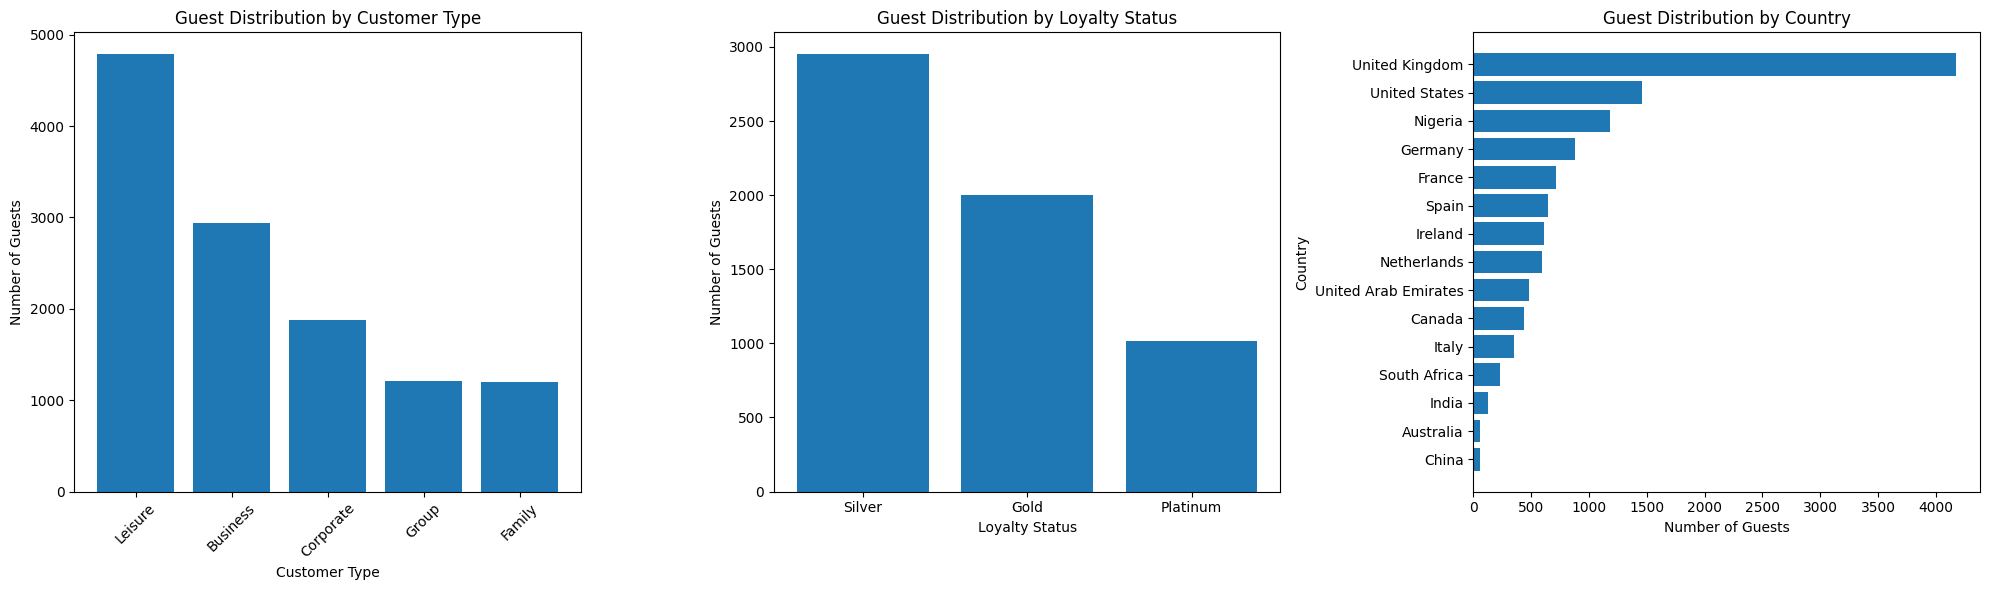

In [23]:
# Visualize the distribution of guest characteristics

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Customer type distribution
axes[0].bar(
    customer_type_summary["customer_type"],
    customer_type_summary["guest_count"]
)
axes[0].set_title("Guest Distribution by Customer Type")
axes[0].set_xlabel("Customer Type")
axes[0].set_ylabel("Number of Guests")
axes[0].tick_params(axis="x", rotation=45)

# Loyalty status distribution
axes[1].bar(
    loyalty_summary["loyalty_status"],
    loyalty_summary["guest_count"]
)
axes[1].set_title("Guest Distribution by Loyalty Status")
axes[1].set_xlabel("Loyalty Status")
axes[1].set_ylabel("Number of Guests")

# Country distribution
axes[2].barh(
    country_summary["country"],
    country_summary["guest_count"]
)
axes[2].set_title("Guest Distribution by Country")
axes[2].set_xlabel("Number of Guests")
axes[2].set_ylabel("Country")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### Finding and Interpretation

The guest dataset contains a diverse range of customer types. **Leisure guests represent the largest customer group with 4,787 guests**, followed by Business guests with 2,934, Corporate guests with 1,876, Group guests with 1,205, and Family guests with 1,198.

Among guests with a recorded loyalty status, **Silver members are the largest group with 2,951 guests**, followed by Gold members with 1,998 and Platinum members with 1,015. However, loyalty status is missing for **6,036 guests**, so the recorded loyalty categories do not represent the complete guest population.

The country distribution shows that guests from the **United Kingdom form the largest represented group with 4,174 guests**, followed by the United States with 1,462 and Nigeria with 1,181. Guests are also represented across several other countries, indicating an internationally diverse customer base.

### Initial Business Insight

The diversity of customer types, loyalty statuses, and countries provides useful context for interpreting guest feedback. Differences in guest experience topics and sentiment can later be examined across relevant guest segments to determine whether particular groups report different experiences.

## 7. Relationship Between Ratings and Guest Reviews

This analysis examines the relationship between guest rating scores and the sentiment labels assigned to their reviews. Understanding this relationship helps determine whether positive, neutral, and negative guest feedback tends to occur at different rating levels.

In [25]:
# Refresh the Neon PostgreSQL database connection

DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL)

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    )
    print("Database connection refreshed successfully!")
    print(result.fetchone())

Database connection refreshed successfully!
('neondb', 'neondb_owner')


In [24]:
# Examine the relationship between rating scores and review sentiment

query = text("""
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        ROUND(AVG(rating_score)::numeric, 2) AS average_rating,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating
    FROM public.reviews
    GROUP BY sentiment_label
    ORDER BY average_rating;
""")

with engine.connect() as connection:
    rating_sentiment = pd.read_sql(query, connection)

display(rating_sentiment)

OperationalError: (psycopg2.OperationalError) SSL connection has been closed unexpectedly

[SQL: 
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        ROUND(AVG(rating_score)::numeric, 2) AS average_rating,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating
    FROM public.reviews
    GROUP BY sentiment_label
    ORDER BY average_rating;
]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [26]:
# Examine the relationship between rating scores and review sentiment

query = text("""
    SELECT
        sentiment_label,
        COUNT(*) AS review_count,
        ROUND(AVG(rating_score)::numeric, 2) AS average_rating,
        MIN(rating_score) AS minimum_rating,
        MAX(rating_score) AS maximum_rating
    FROM public.reviews
    GROUP BY sentiment_label
    ORDER BY average_rating;
""")

with engine.connect() as connection:
    rating_sentiment = pd.read_sql(query, connection)

display(rating_sentiment)

,sentiment_label,review_count,average_rating,minimum_rating,maximum_rating
0,negative,9863,1.94,1.0,3.4
1,neutral,13355,2.96,1.0,5.0
2,positive,11782,4.01,2.5,5.0


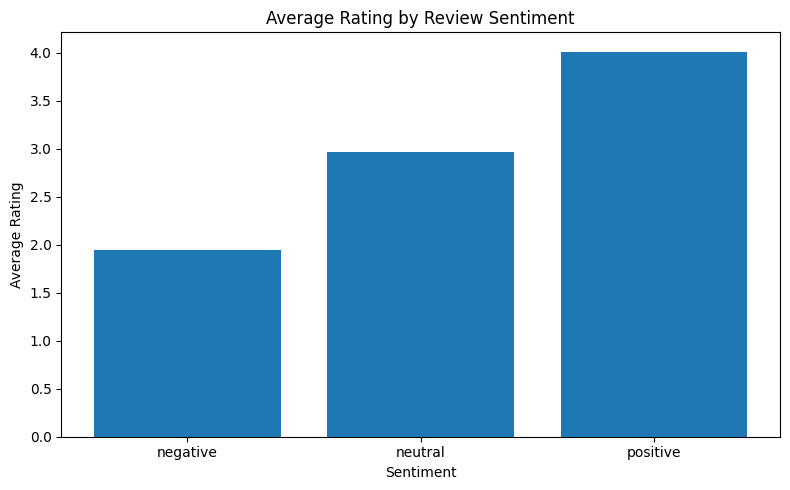

In [27]:
# Visualize the relationship between sentiment and average rating

plt.figure(figsize=(8, 5))

plt.bar(
    rating_sentiment["sentiment_label"],
    rating_sentiment["average_rating"]
)

plt.title("Average Rating by Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

### Finding and Interpretation

The analysis shows a clear relationship between guest ratings and review sentiment. Negative reviews have the lowest average rating at **1.94**, while neutral reviews have an average rating of **2.96**. Positive reviews have the highest average rating at **4.01**.

The rating ranges also show that negative reviews have ratings between **1.0 and 3.4**, while positive reviews range from **2.5 to 5.0**. Neutral reviews span the full rating range from **1.0 to 5.0**.

Overall, the results indicate that lower ratings are generally associated with negative review sentiment, while higher ratings are generally associated with positive sentiment.

### Initial Business Insight

The relationship between rating scores and sentiment provides an important basis for further guest experience analysis. Reviews with lower ratings can be examined to identify the topics and issues contributing to negative guest experiences, while positive reviews can help identify aspects of the hotel experience that guests value.

## 8. Notable Patterns and Areas for Further Investigation

The exploratory analysis identified several patterns in the guest review dataset that can guide subsequent guest experience and NLP analysis.

The dataset contains **35,000 guest reviews** covering **25 hotels**, with review volumes relatively evenly distributed across the properties. This provides a useful basis for comparing guest experiences across hotels.

Guest ratings range from **1.0 to 5.0**, with a concentration around the middle of the rating scale. The review text is complete across the dataset, with no null or empty review texts, and reviews range from **67 to 280 characters** with an average length of approximately **171.91 characters**. These characteristics indicate that the review text provides a suitable source for subsequent NLP analysis.

The review data also covers a continuous period from **January 2025 to June 2026**, although the number of reviews varies across months. This variation should be considered when examining changes in guest sentiment or experience topics over time.

The guest population includes different customer types, loyalty statuses, and countries, with **Leisure guests** and guests from the **United Kingdom** representing the largest recorded groups. Loyalty status is missing for a substantial proportion of guests and should therefore be treated carefully in subsequent analysis.

A clear relationship was also observed between rating scores and sentiment. Negative reviews have a lower average rating (**1.94**) than neutral reviews (**2.96**) and positive reviews (**4.01**). This suggests that rating and sentiment provide complementary information about guest experiences.

### Areas for Further Investigation

Based on these findings, further analysis should investigate:

- The main topics and recurring issues discussed in guest reviews using **BERTopic**.
- The sentiment associated with individual guest experience topics.
- The differences in guest experience topics and sentiment across hotels.
- The characteristics of reviews associated with low and high rating scores.
- Potential differences in guest feedback across relevant customer segments.
- Misclassified or ambiguous sentiment cases during subsequent sentiment model evaluation.

These areas will help move the analysis from descriptive exploration toward identifying the specific factors that influence guest experience and satisfaction.

# NLP Preprocessing & Review Corpus

This section prepares the guest review text for subsequent natural language processing tasks, including topic modelling and sentiment analysis.

The preprocessing workflow will focus on cleaning and normalising the review text while preserving meaningful words and contextual information. The process will include selecting the required review text, inspecting the corpus, handling unusable records, removing unnecessary noise, applying suitable text-processing techniques, and validating the final corpus for downstream NLP analysis.

In [5]:
# Reload required libraries after the Colab runtime reset

import pandas as pd
import re
import unicodedata

from sqlalchemy import create_engine, text
from google.colab import userdata

print("Required libraries reloaded successfully.")

Required libraries reloaded successfully.


In [8]:
# Reconnect to the Neon PostgreSQL database

DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL)

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    )
    print("Database connection refreshed successfully!")
    print(result.fetchone())

Database connection refreshed successfully!
('neondb', 'neondb_owner')


In [9]:
# Recreate the review corpus for NLP processing

query = text("""
    SELECT
        review_id,
        hotel_id,
        review_text,
        sentiment_label
    FROM public.reviews
    WHERE review_text IS NOT NULL
      AND TRIM(review_text) <> ''
    ORDER BY review_id;
""")

with engine.connect() as connection:
    review_corpus = pd.read_sql(query, connection)

print(f"Number of usable review records: {len(review_corpus):,}")
display(review_corpus.head())

Number of usable review records: 35,000


,review_id,hotel_id,review_text,sentiment_label
0,1,18,The overall price was fair for what we paid. M...,neutral
1,2,23,The room was nothing out of the ordinary for w...,positive
2,3,13,"Unfortunately, the pool was outdated — it clea...",negative
3,4,12,We were disappointed that the neighborhood was...,negative
4,5,5,The room service was standard hotel fare for w...,neutral


In [10]:
# Restore the reusable NLP preprocessing function

def preprocess_review(text):
    """
    Clean and normalize guest review text while preserving
    meaningful words and contextual information.
    """

    # Convert to string and normalize Unicode characters
    text = str(text)
    text = unicodedata.normalize("NFKC", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove HTML tags if present
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize apostrophes and quotation marks
    text = text.replace("’", "'").replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')

    # Replace unusual dash characters with a standard space
    text = re.sub(r"[‐-‒–—―]", " ", text)

    # Remove non-printing/control characters
    text = "".join(
        char for char in text
        if char.isprintable()
    )

    # Normalize repeated whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing whitespace
    text = text.strip()

    return text

print("NLP preprocessing function restored successfully.")


NLP preprocessing function restored successfully.


In [11]:
# Apply the preprocessing function to the review corpus

review_corpus["clean_review_text"] = review_corpus["review_text"].apply(
    preprocess_review
)

print("Preprocessing applied successfully.")

display(
    review_corpus[
        ["review_id", "review_text", "clean_review_text"]
    ].head(10)
)

Preprocessing applied successfully.


,review_id,review_text,clean_review_text
0,1,The overall price was fair for what we paid. M...,The overall price was fair for what we paid. M...
1,2,The room was nothing out of the ordinary for w...,The room was nothing out of the ordinary for w...
2,3,"Unfortunately, the pool was outdated — it clea...","Unfortunately, the pool was outdated it clearl..."
3,4,We were disappointed that the neighborhood was...,We were disappointed that the neighborhood was...
4,5,The room service was standard hotel fare for w...,The room service was standard hotel fare for w...
5,6,Getting around from the hotel was in a rather ...,Getting around from the hotel was in a rather ...
6,7,We couldn't have asked for a better base while...,We couldn't have asked for a better base while...
7,8,We had a wonderful time during our stay in Not...,We had a wonderful time during our stay in Not...
8,9,The in-house cafe was acceptable for what we p...,The in-house cafe was acceptable for what we p...
9,10,"The manager was fine, nothing special for what...","The manager was fine, nothing special for what..."


In [12]:
# Validate the cleaned review corpus

cleaned_corpus_quality = pd.DataFrame({
    "Metric": [
        "Total reviews",
        "Missing cleaned reviews",
        "Empty cleaned reviews",
        "Shortest cleaned review (characters)",
        "Longest cleaned review (characters)",
        "Average cleaned review length (characters)"
    ],
    "Value": [
        len(review_corpus),
        review_corpus["clean_review_text"].isna().sum(),
        (review_corpus["clean_review_text"].str.strip() == "").sum(),
        review_corpus["clean_review_text"].str.len().min(),
        review_corpus["clean_review_text"].str.len().max(),
        round(review_corpus["clean_review_text"].str.len().mean(), 2)
    ]
})

display(cleaned_corpus_quality)

,Metric,Value
0,Total reviews,35000.0
1,Missing cleaned reviews,0.0
2,Empty cleaned reviews,0.0
3,Shortest cleaned review (characters),67.0
4,Longest cleaned review (characters),278.0
5,Average cleaned review length (characters),171.2


In [28]:
# Refresh the Neon PostgreSQL database connection

DATABASE_URL = userdata.get("DATABASE_URL")
engine = create_engine(DATABASE_URL)

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    )
    print("Database connection refreshed successfully!")
    print(result.fetchone())

Database connection refreshed successfully!
('neondb', 'neondb_owner')


In [29]:
# Select the review text required for NLP processing

query = text("""
    SELECT
        review_id,
        hotel_id,
        review_text,
        sentiment_label
    FROM public.reviews
    WHERE review_text IS NOT NULL
      AND TRIM(review_text) <> ''
    ORDER BY review_id;
""")

with engine.connect() as connection:
    review_corpus = pd.read_sql(query, connection)

print(f"Number of usable review records: {len(review_corpus):,}")
display(review_corpus.head())

Number of usable review records: 35,000


,review_id,hotel_id,review_text,sentiment_label
0,1,18,The overall price was fair for what we paid. M...,neutral
1,2,23,The room was nothing out of the ordinary for w...,positive
2,3,13,"Unfortunately, the pool was outdated — it clea...",negative
3,4,12,We were disappointed that the neighborhood was...,negative
4,5,5,The room service was standard hotel fare for w...,neutral


## 1. Review Corpus Quality Inspection

The review corpus is inspected before preprocessing to identify missing or unusable text, duplicate records, review-length characteristics, and other basic text-quality issues.

This inspection helps determine which preprocessing steps are necessary while ensuring that meaningful contextual information is preserved.

In [30]:
# Inspect the quality and characteristics of the review corpus

corpus_quality = pd.DataFrame({
    "Metric": [
        "Total review records",
        "Missing review text",
        "Empty review text",
        "Duplicate review IDs",
        "Duplicate review texts",
        "Shortest review (characters)",
        "Longest review (characters)",
        "Average review length (characters)"
    ],
    "Value": [
        len(review_corpus),
        review_corpus["review_text"].isna().sum(),
        (review_corpus["review_text"].str.strip() == "").sum(),
        review_corpus["review_id"].duplicated().sum(),
        review_corpus["review_text"].duplicated().sum(),
        review_corpus["review_text"].str.len().min(),
        review_corpus["review_text"].str.len().max(),
        round(review_corpus["review_text"].str.len().mean(), 2)
    ]
})

display(corpus_quality)

,Metric,Value
0,Total review records,35000.00
1,Missing review text,0.00
2,Empty review text,0.00
3,Duplicate review IDs,0.00
4,Duplicate review texts,464.00
5,Shortest review (characters),67.00
6,Longest review (characters),280.00
7,Average review length (characters),171.91


### Corpus Quality Findings

The review corpus contains **35,000 usable review records**. There are no missing or empty review texts, and all review IDs are unique.

A total of **464 review texts are repeated**. These repeated texts are retained at this stage because identical text does not necessarily indicate an invalid record or duplicate review transaction. The review records may represent legitimate observations associated with different guests or hotels.

Review lengths range from **67 to 280 characters**, with an average length of **171.91 characters**. This indicates that the corpus contains sufficiently detailed text for subsequent natural language processing while remaining relatively concise.

Overall, the corpus is complete and suitable for further preprocessing. The next stage will focus on removing unnecessary textual noise while preserving meaningful words and contextual information.

In [31]:
# Inspect sample reviews before preprocessing

sample_reviews = review_corpus[
    ["review_id", "review_text"]
].sample(10, random_state=42)

display(sample_reviews)

,review_id,review_text
17813,17814,"Unfortunately, the dining options was overpric..."
6857,6858,"This hotel was a fine, if unremarkable, choice..."
7672,7673,Our stay in Birmingham was fairly ordinary. Me...
9704,9705,"This hotel was a fine, if unremarkable, choice..."
14303,14304,The carpet was clean enough for what we paid. ...
26304,26305,I'd describe the overall price as in line with...
3202,3203,"Overall the receptionist was acceptable, about..."
27310,27311,I'd describe the overall price as about what w...
11215,11216,We had a wonderful time during our stay in Man...
20490,20491,Nothing about our visit to Birmingham stood ou...


In [32]:
# Create a reusable NLP preprocessing function

import re
import unicodedata

def preprocess_review(text):
    """
    Clean and normalize guest review text while preserving
    meaningful words and contextual information.
    """

    # Convert to string and normalize Unicode characters
    text = str(text)
    text = unicodedata.normalize("NFKC", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove HTML tags if present
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize apostrophes and quotation marks
    text = text.replace("’", "'").replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')

    # Replace unusual dash characters with a standard space
    text = re.sub(r"[‐-‒–—―]", " ", text)

    # Remove non-printing/control characters
    text = "".join(
        char for char in text
        if char.isprintable()
    )

    # Normalize repeated whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing whitespace
    text = text.strip()

    return text

In [33]:
# Apply the preprocessing function to the review corpus

review_corpus["clean_review_text"] = review_corpus["review_text"].apply(
    preprocess_review
)

print("Preprocessing applied successfully.")
display(
    review_corpus[
        ["review_id", "review_text", "clean_review_text"]
    ].head(10)
)

Preprocessing applied successfully.


,review_id,review_text,clean_review_text
0,1,The overall price was fair for what we paid. M...,The overall price was fair for what we paid. M...
1,2,The room was nothing out of the ordinary for w...,The room was nothing out of the ordinary for w...
2,3,"Unfortunately, the pool was outdated — it clea...","Unfortunately, the pool was outdated it clearl..."
3,4,We were disappointed that the neighborhood was...,We were disappointed that the neighborhood was...
4,5,The room service was standard hotel fare for w...,The room service was standard hotel fare for w...
5,6,Getting around from the hotel was in a rather ...,Getting around from the hotel was in a rather ...
6,7,We couldn't have asked for a better base while...,We couldn't have asked for a better base while...
7,8,We had a wonderful time during our stay in Not...,We had a wonderful time during our stay in Not...
8,9,The in-house cafe was acceptable for what we p...,The in-house cafe was acceptable for what we p...
9,10,"The manager was fine, nothing special for what...","The manager was fine, nothing special for what..."


In [2]:
# Reload pandas for the current Colab session

import pandas as pd

print("Pandas imported successfully.")

Pandas imported successfully.


In [7]:
# Validate the cleaned review corpus

cleaned_corpus_quality = pd.DataFrame({
    "Metric": [
        "Total reviews",
        "Missing cleaned reviews",
        "Empty cleaned reviews",
        "Shortest cleaned review (characters)",
        "Longest cleaned review (characters)",
        "Average cleaned review length (characters)"
    ],
    "Value": [
        len(review_corpus),
        review_corpus["clean_review_text"].isna().sum(),
        (review_corpus["clean_review_text"].str.strip() == "").sum(),
        review_corpus["clean_review_text"].str.len().min(),
        review_corpus["clean_review_text"].str.len().max(),
        round(review_corpus["clean_review_text"].str.len().mean(), 2)
    ]
})

display(cleaned_corpus_quality)

NameError: name 'review_corpus' is not defined

In [6]:
# Validate the cleaned review corpus

cleaned_corpus_quality = pd.DataFrame({
    "Metric": [
        "Total reviews",
        "Missing cleaned reviews",
        "Empty cleaned reviews",
        "Shortest cleaned review (characters)",
        "Longest cleaned review (characters)",
        "Average cleaned review length (characters)"
    ],
    "Value": [
        len(review_corpus),
        review_corpus["clean_review_text"].isna().sum(),
        (review_corpus["clean_review_text"].str.strip() == "").sum(),
        review_corpus["clean_review_text"].str.len().min(),
        review_corpus["clean_review_text"].str.len().max(),
        round(review_corpus["clean_review_text"].str.len().mean(), 2)
    ]
})

display(cleaned_corpus_quality)

NameError: name 'review_corpus' is not defined